Shape: (545, 13)

First 5 rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Missing Values:
price               0
area                0
bedroo

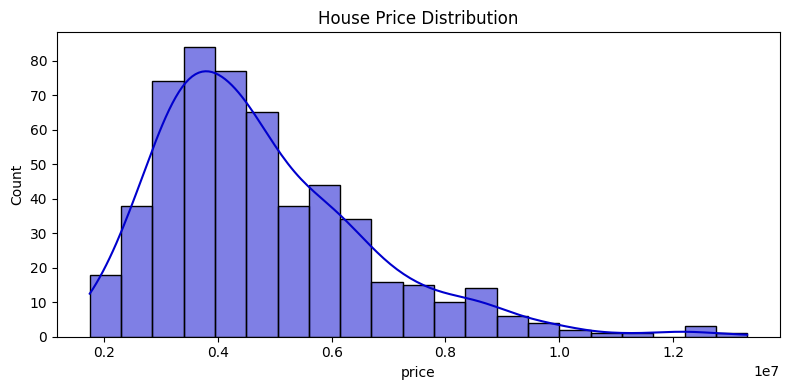

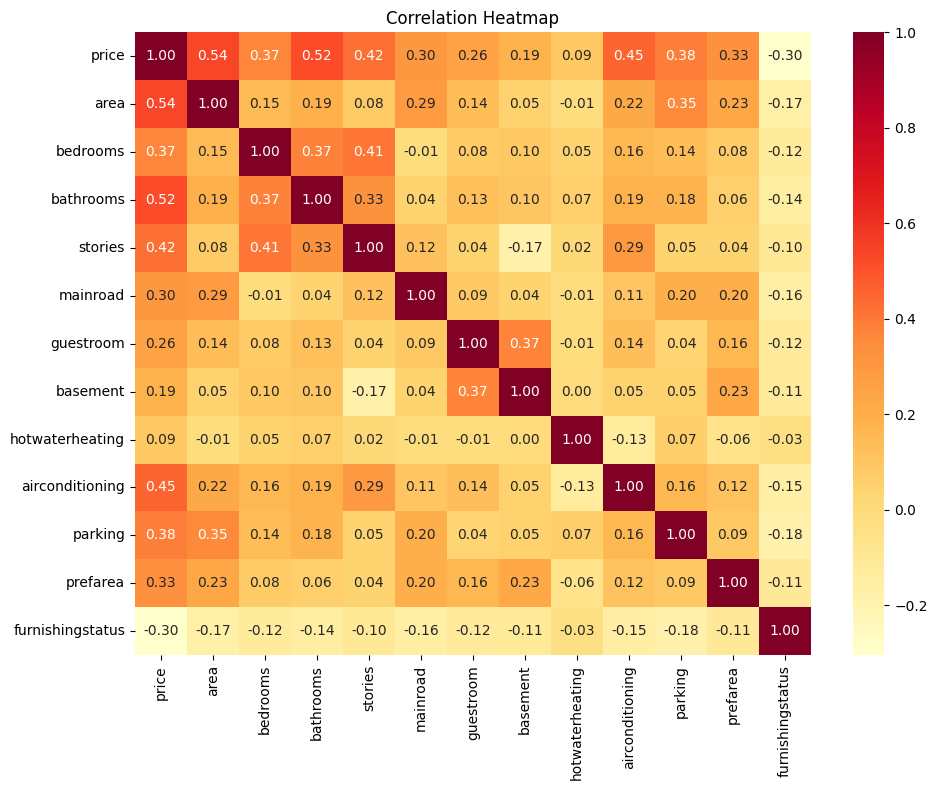


Linear Regression → MAE: 979,680 | RMSE: 1,331,071
Gradient Boosting → MAE: 975,823 | RMSE: 1,316,474


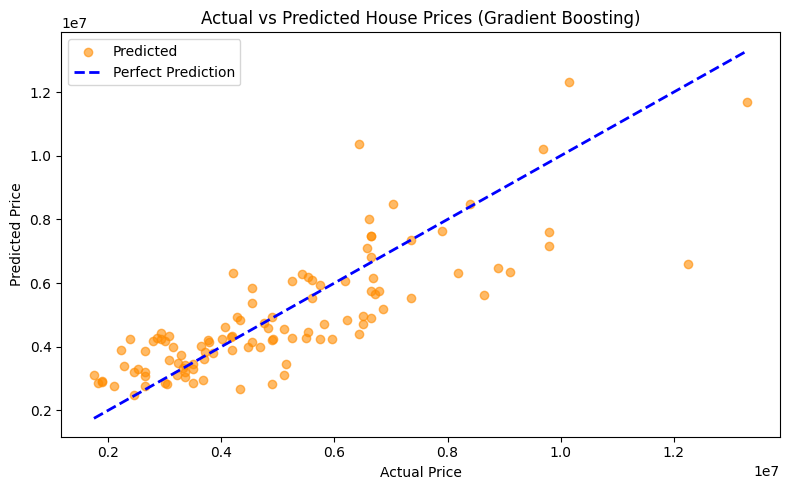


✅ Task 6 Complete!


In [2]:
# --- 1. Imports ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# --- 2. Load Dataset ---
df = pd.read_csv('Housing.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

# --- 3. Encode Categorical Columns ---
le = LabelEncoder()
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("\nAfter Encoding:")
print(df.dtypes)

# --- 4. EDA ---
plt.figure(figsize=(8, 4))
sns.histplot(df['price'], kde=True, color='mediumblue')
plt.title('House Price Distribution')
plt.tight_layout()
plt.savefig('price_distribution.png')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_house.png')
plt.show()

# --- 5. Prepare Features ---
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 6. Train Linear Regression ---
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
print(f"\nLinear Regression → MAE: {lr_mae:,.0f} | RMSE: {lr_rmse:,.0f}")

# --- 7. Train Gradient Boosting ---
gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_preds)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))
print(f"Gradient Boosting → MAE: {gb_mae:,.0f} | RMSE: {gb_rmse:,.0f}")

# --- 8. Actual vs Predicted Plot ---
plt.figure(figsize=(8, 5))
plt.scatter(y_test, gb_preds, alpha=0.6, color='darkorange', label='Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'b--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices (Gradient Boosting)')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()

print("\n✅ Task 6 Complete!")